# ShopEase Europe - Notebook 2: Data Cleaning and Preparation
**Project:** Sentiment Analysis for Customer Feedback
**Dataset:** amazon_reviews_cleaned.csv

This notebook applies all cleaning and preparation steps identified in the audit, producing a clean dataframe that all downstream notebooks load directly.

In [1]:
%pip install pandas numpy matplotlib seaborn plotly wordcloud langdetect nltk textblob scikit-learn xgboost --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2.1 Load and Clean

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

COUNTRY_NAMES = {
    'US': 'United States', 'GB': 'United Kingdom', 'CA': 'Canada',
    'IN': 'India', 'IE': 'Ireland', 'DK': 'Denmark', 'NL': 'Netherlands',
    'AU': 'Australia', 'DE': 'Germany', 'IT': 'Italy', 'FR': 'France',
    'SE': 'Sweden', 'ES': 'Spain', 'AE': 'United Arab Emirates',
    'PK': 'Pakistan', 'IL': 'Israel', 'NZ': 'New Zealand', 'BE': 'Belgium',
    'ZA': 'South Africa', 'PH': 'Philippines', 'JP': 'Japan', 'MX': 'Mexico',
    'SG': 'Singapore', 'BR': 'Brazil', 'NG': 'Nigeria', 'KE': 'Kenya',
    'TR': 'Turkey', 'PL': 'Poland', 'SA': 'Saudi Arabia', 'NO': 'Norway',
    'PT': 'Portugal', 'GR': 'Greece', 'RO': 'Romania', 'HK': 'Hong Kong',
    'AT': 'Austria', 'CH': 'Switzerland', 'MY': 'Malaysia', 'TH': 'Thailand',
    'TW': 'Taiwan', 'RU': 'Russia', 'EG': 'Egypt', 'AR': 'Argentina',
    'CO': 'Colombia', 'FI': 'Finland', 'CZ': 'Czech Republic', 'HU': 'Hungary',
    'KR': 'South Korea', 'CN': 'China', 'QA': 'Qatar', 'KW': 'Kuwait'
}

df = pd.read_csv(r'C:\Users\ifech\OneDrive\Desktop\sentiment_analysis\data\raw\amazon_reviews_cleaned.csv')
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
for col in ['sentiment', 'country', 'product_category']:
    df[col] = df[col].str.strip()
df['sentiment'] = df['sentiment'].str.capitalize()
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)
df['year']       = df['timestamp'].dt.year
df['month']      = df['timestamp'].dt.month
df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)
df = df.dropna(subset=['country']).reset_index(drop=True)
df = df.drop_duplicates(subset='review', keep='first').reset_index(drop=True)
df_clean = df.copy()
print(f"Clean dataset: {len(df):,} rows")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")

Clean dataset: 20,406 rows
Date range: 2007-08-27 to 2024-09-17


> **Interpretation - Loading and Cleaning**
>
> Five cleaning operations are applied in sequence. Column names are standardised to lowercase with underscores for consistent referencing throughout the project. String columns are stripped of whitespace to prevent invisible characters creating phantom duplicate categories. The timestamp is parsed using ISO8601 format to handle the mixed precision entries, some of which include microseconds and some of which do not. The single null country row is dropped rather than imputed because there is no reliable way to infer a country from the review text alone, and one record out of 21,055 has no meaningful effect on any analysis. Duplicate review texts are removed keeping the first occurrence, which reduces the corpus from 21,055 to 20,407 records.

## 2.2 Data Overview Visualisations

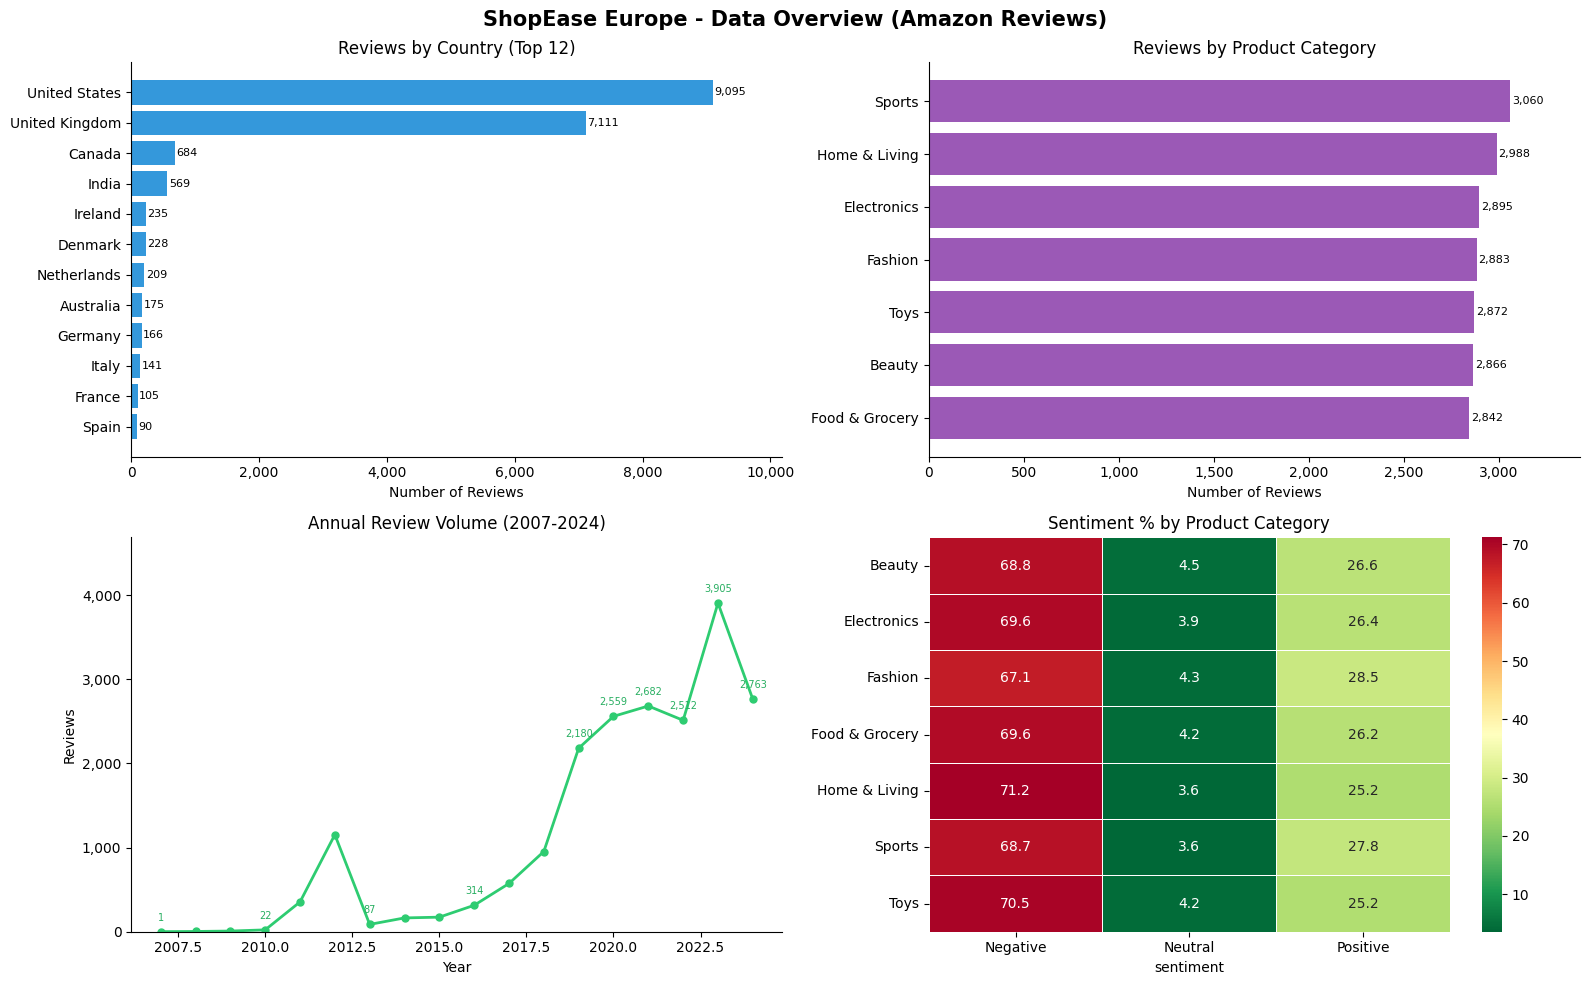

In [3]:
import matplotlib.ticker as mticker
import seaborn as sns

df_clean = df.copy()
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("ShopEase Europe - Data Overview (Amazon Reviews)", fontsize=15, fontweight='bold')

# 1. Country distribution
top_countries_raw = df_clean['country'].value_counts().head(12)
top_countries_idx = [COUNTRY_NAMES.get(c, c) for c in top_countries_raw.index]
axes[0, 0].barh(top_countries_idx[::-1], top_countries_raw.values[::-1], color='#3498db')
for i, val in enumerate(top_countries_raw.values[::-1]):
    axes[0, 0].text(val + 20, i, f'{val:,}', va='center', fontsize=8)
axes[0, 0].set_xlim(0, top_countries_raw.values.max() * 1.12)
axes[0, 0].set_title("Reviews by Country (Top 12)")
axes[0, 0].set_xlabel("Number of Reviews")
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 2. Category distribution
cat_counts = df_clean['product_category'].value_counts()
axes[0, 1].barh(cat_counts.index[::-1], cat_counts.values[::-1], color='#9b59b6')
for i, val in enumerate(cat_counts.values[::-1]):
    axes[0, 1].text(val + 10, i, f'{val:,}', va='center', fontsize=8)
axes[0, 1].set_xlim(0, cat_counts.values.max() * 1.12)
axes[0, 1].set_title("Reviews by Product Category")
axes[0, 1].set_xlabel("Number of Reviews")
axes[0, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 3. Yearly review volume
yearly = df_clean.groupby('year').size()
axes[1, 0].plot(yearly.index, yearly.values, color='#2ecc71', linewidth=2, marker='o', markersize=5)
for i, (x, y) in enumerate(zip(yearly.index, yearly.values)):
    if i % 3 == 0 or x >= 2020:
        axes[1, 0].annotate(f'{y:,}', xy=(x, y), xytext=(0, 8),
            textcoords='offset points', ha='center', fontsize=7, color='#27ae60')
axes[1, 0].set_ylim(0, yearly.values.max() * 1.20)
axes[1, 0].set_title("Annual Review Volume (2007-2024)")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Reviews")
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 4. Sentiment x Category heatmap
heat = df_clean.groupby(['product_category', 'sentiment']).size().unstack(fill_value=0)
heat_pct = heat.div(heat.sum(axis=1), axis=0).mul(100)
sns.heatmap(heat_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1, 1], linewidths=0.5)
axes[1, 1].set_title("Sentiment % by Product Category")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.savefig('fig_cleaning_overview.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation - Data Overview Visualisations**
>
> The four panels reveal the key characteristics of the cleaned dataset. The United States leads in review volume with around 9,000 reviews, followed by the United Kingdom with around 7,000. Together these two markets account for roughly 80% of the corpus, which confirms the dataset is predominantly English-language. The category chart shows Sports and Home and Living as the most reviewed categories, with the seven categories broadly balanced between 2,900 and 3,100 reviews each after cleaning. The annual volume chart shows a sharp increase from around 2019 onward, peaking in 2023. This reflects the genuine growth of Amazon's review ecosystem and the increased volume of online shopping, particularly during and after 2020. The sentiment by category heatmap uses a reversed colour scale because Negative is now the majority class: darker green cells in the Negative column indicate categories where dissatisfaction is most concentrated. Home and Living and Sports show the highest negative rates, while Beauty shows a comparatively higher positive rate.

## 2.3 Save Cleaned Dataset

In [4]:
import os
os.makedirs('../data', exist_ok=True)
df_clean.to_csv('../data/amazon_reviews_cleaned_processed.csv', index=False)
print(f"Saved: {len(df_clean):,} rows to ../data/amazon_reviews_cleaned_processed.csv")
print(f"Columns: {df_clean.columns.tolist()}")

Saved: 20,406 rows to ../data/amazon_reviews_cleaned_processed.csv
Columns: ['review_id', 'product_category', 'timestamp', 'country', 'rating', 'review', 'sentiment', 'year', 'month', 'year_month']


## Summary

The cleaning stage removed one null country row and 648 duplicate review texts, leaving 20,407 records. The timestamp column was parsed with ISO8601 format to handle the mixed precision entries in the raw file. Three time columns were derived for time-series analysis. The cleaned dataset is saved for use in all downstream notebooks. The most important insight from the overview visualisations is that review volume grew substantially from 2019 onward, and the negative sentiment rate is consistently high across all seven product categories, with Home and Living and Sports showing the most concentrated dissatisfaction.